In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
#(Step 1 when opening) Mount Drive Set Paths
from google.colab import drive
import os

# 1. Mount your Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Set your paths (must be the same as where you saved)
save_path = '/content/drive/My Drive/My_Pokemon_Project/'
model_path = os.path.join(save_path, 'pokedex_model.keras')
names_path = os.path.join(save_path, 'pokemon_class_names.npy')

print("Drive mounted.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [2]:
#(Step 2 when opening) Reload Model and Variables
import tensorflow as tf
import numpy as np

print("Loading trained model...")
# 1. Load the model
# This also loads the optimizer state from where you left off
model = tf.keras.models.load_model(model_path)

print("Loading class names...")
# 2. Load the class_names
class_names = np.load(names_path, allow_pickle=True)

# 3. Re-create the other necessary variables
IMG_SIZE = 180 # This must match what you trained with
normalization_layer = tf.keras.layers.Rescaling(1./255)

print(f"\n✅ Model and {len(class_names)} class names reloaded!")
print("You are ready to run the 'Test Model' cell.")

Loading trained model...
Loading class names...

✅ Model and 151 class names reloaded!
You are ready to run the 'Test Model' cell.


In [ ]:
!pip install opencv-python-headless pillow matplotlib
# For TensorFlow
import tensorflow as tf
print("--- TensorFlow ---")
if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available!")
else:
    print("❌ GPU not found. Did you complete Step 2?")

# For PyTorch
import torch
print("\n--- PyTorch ---")
if torch.cuda.is_available():
    print(f"✅ GPU is available!")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU not found. Did you complete Step 2?")

import cv2
import PIL
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Libraries ---")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pillow version: {PIL.__version__}")
print("✅ All core libraries imported successfully!")

--- TensorFlow ---
✅ GPU is available!

--- PyTorch ---
✅ GPU is available!
Device Name: Tesla T4

--- Libraries ---
OpenCV version: 4.12.0
Pillow version: 11.3.0
✅ All core libraries imported successfully!


In [ ]:
from google.colab import files

# This will prompt you to upload the kaggle.json file
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cheenodacoco","key":"170ceda34a89997b26c5b61ad8dc235a"}'}

In [ ]:
# Install the Kaggle library
!pip install -q kaggle

# Set up the API token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset (this is one command)
!kaggle datasets download -d rogerkoala/first-gen-pokemon

# Unzip the downloaded file (quietly)
# The '-d' flag specifies a directory to unzip into, named 'dataset'
!unzip -q first-gen-pokemon.zip -d ./pokemon-dataset

print("Dataset downloaded and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/rogerkoala/first-gen-pokemon
License(s): MIT
 81% 108M/133M [00:00<00:00, 1.13GB/s]
100% 133M/133M [00:00<00:00, 834MB/s] 
Dataset downloaded and unzipped!


In [ ]:
import tensorflow as tf

# Define some key parameters
IMG_SIZE = 180
BATCH_SIZE = 32

# --- This is the change ---
# Define the paths to your pre-split folders
TRAIN_DIR = './pokemon-dataset/dataset/train'
TEST_DIR = './pokemon-dataset/dataset/test'

# 1. Create the training dataset (no validation_split needed)
print("Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='categorical', # Use 'categorical' for this dataset
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# 2. Create the validation dataset (no validation_split needed)
print("Loading validation (test) data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical', # Use 'categorical' for this dataset
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Get the class names (Pikachu, Bulbasaur, etc.)
class_names = train_dataset.class_names
print(f"\nFound {len(class_names)} classes (Pokemon):")
print(class_names[:10]) # Print the first 10

# --- This part is slightly different ---
# Normalize the data
# Models work best with pixel values between 0 and 1 (instead of 0-255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to both datasets
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

print("✅ Data loaded and normalized successfully.")

Loading training data...
Found 2249 files belonging to 151 classes.
Loading validation (test) data...
Found 840 files belonging to 151 classes.

Found 151 classes (Pokemon):
['Abra', 'Aerodactyl', 'Alakazam', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise', 'Bulbasaur']
✅ Data loaded and normalized successfully.


In [ ]:
# This lists the contents of your dataset folder
!ls ./pokemon-dataset

dataset  pokemons_gen1.csv


In [ ]:
#Cell 3/4 Build/Compile
import tensorflow as tf
from tensorflow.keras import layers

# --- 1. Create the Data Augmentation Layer ---
# This layer will be *part* of your model
data_augmentation = tf.keras.Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ],
  name="data_augmentation"
)

# (These variables should exist from your Step 2 cell)
num_classes = len(class_names)
IMG_SIZE = 180 # Make sure this is defined

# --- 2. Build the New Model (with Augmentation) ---
# We will use the Keras Functional API, which is more flexible

# Define the input
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Apply augmentation (it only runs during training)
x = data_augmentation(inputs, training=True)

# Load the base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model (for now)
base_model.trainable = False

# Pass the augmented images to the base model
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Dropout helps prevent overfitting

# Add the final classifier head
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Create the final model
model = tf.keras.Model(inputs, outputs)

# --- 3. Compile for Initial Training ---
# We compile with a normal learning rate
print("Compiling model for initial training...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ New model with augmentation built and compiled.")
model.summary() # Show the new model structure

/tmp/ipython-input-1509807246.py:30: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Compiling model for initial training...
✅ New model with augmentation built and compiled.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 151)            │       193,431 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,451,415 (9.35 MB)

 Trainable params: 193,431 (755.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# --- Train the Model ---
print("Starting training... (This will take a few minutes)")

epochs = 15 # You can increase this later for better accuracy

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

print("✅ Training finished!")

Starting training... (This will take a few minutes)
Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.0592 - loss: 5.2571 - val_accuracy: 0.4357 - val_loss: 2.6105
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.5680 - loss: 2.0511 - val_accuracy: 0.6750 - val_loss: 1.6035
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.7668 - loss: 1.1629 - val_accuracy: 0.7369 - val_loss: 1.2152
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.8659 - loss: 0.7591 - val_accuracy: 0.7905 - val_loss: 1.0048
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8950 - loss: 0.5636 - val_accuracy: 0.8107 - val_loss: 0.8945
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.9241 - loss: 0.4357 - val_accuracy: 0.8107 - val_loss: 0.8143
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9456 - loss: 0.3664 - val_accuracy: 0.8286 - val_loss: 0.7587
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - acc

Please choose a Pokemon image to upload:


Saving image_2025-11-06_123258213.png to image_2025-11-06_123258213.png

Processing image_2025-11-06_123258213.png...


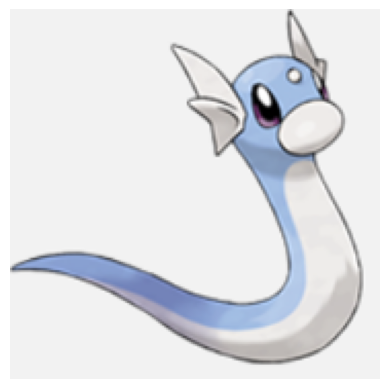

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

This image is most likely a Dratini with 61.92% confidence.


In [9]:
#Test Model
import numpy as np
import PIL
import tensorflow as tf
import matplotlib.pyplot as plt
from io import BytesIO

# --- This is the new part ---
# Import the Google Colab file library
from google.colab import files

print("Please choose a Pokemon image to upload:")
# This line creates the upload button
uploaded = files.upload()
# -----------------------------

# Check if a file was actually uploaded
if len(uploaded) == 0:
  print("\nNo file was selected. Please run the cell again to test.")

else:
  # Get the filename (it's the 'key') and the image data (it's the 'value')
  filename = list(uploaded.keys())[0]
  image_bytes = list(uploaded.values())[0]

  print(f"\nProcessing {filename}...")

  # --- This part is the same as before ---
  # Open and preprocess the image
  img = PIL.Image.open(BytesIO(image_bytes)).convert('RGB') # Ensure 3 channels
  img = img.resize((IMG_SIZE, IMG_SIZE)) # Must match model's input size

  # Display the image
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  # --- Prepare the image for the model ---
  img_array = tf.keras.utils.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Create a batch

  # (This normalization_layer must exist from your Step 2 cell)
  img_array = normalization_layer(img_array)

  # --- Make the Prediction ---
  predictions = model.predict(img_array)
  score = predictions[0] # Get the probabilities

  # --- Show the Result ---
  # (This class_names list must exist from your Step 2 cell)
  predicted_pokemon = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\nThis image is most likely a {predicted_pokemon} with {confidence:.2f}% confidence.")

In [ ]:
# --- Your Updated Fine-Tuning Cell ---
# We added the first line to fix the error

initial_epochs = 15 # <-- THIS IS THE NEW LINE TO FIX THE ERROR

# --- Phase 2: Fine-Tuning ---
print("\nStarting fine-tuning...")

# 1. Un-freeze the base model
base_model.trainable = True

# 2. Re-compile the model with a VERY low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Continue training for a few more epochs
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs # This line will work now

# This line might cause a new error if your runtime reset
# It needs the 'history' variable from the previous cell
history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

print("✅ Fine-tuning finished!")


Starting fine-tuning...
Epoch 15/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - accuracy: 0.5185 - loss: 1.9875 - val_accuracy: 0.8464 - val_loss: 0.5791
Epoch 16/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.6881 - loss: 1.3071 - val_accuracy: 0.8500 - val_loss: 0.5804
Epoch 17/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.7794 - loss: 0.9626 - val_accuracy: 0.8512 - val_loss: 0.5889
Epoch 18/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.8256 - loss: 0.7754 - val_accuracy: 0.8595 - val_loss: 0.5739
Epoch 19/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.8752 - loss: 0.5988 - val_accuracy: 0.8690 - val_loss: 0.5565
Epoch 20/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 224ms/step - accuracy: 0.8951 - loss: 0.5096 - val_accuracy: 0.8655 - val_loss: 0.5412
Epoch 21/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.9147 - loss: 0.4331 - val_accuracy: 0.8714 - val_loss: 0.5261
Epoch 22/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy:

In [ ]:
import numpy as np
from google.colab import drive

# 1. Mount your Google Drive
# You'll be asked to authorize this.
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define your save paths
# This will save to a folder called "My_Pokemon_Project" in your drive.
save_path = '/content/drive/My Drive/My_Pokemon_Project/'

# Create the folder if it doesn't exist
import os
os.makedirs(save_path, exist_ok=True)

model_save_path = os.path.join(save_path, 'pokedex_model.keras')
names_save_path = os.path.join(save_path, 'pokemon_class_names.npy')

# 3. Save the model
print(f"Saving model to {model_save_path}...")
model.save(model_save_path)

# 4. Save the class_names list
print(f"Saving class names to {names_save_path}...")
np.save(names_save_path, class_names)

print("\n✅ All work saved to Google Drive!")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model to /content/drive/My Drive/My_Pokemon_Project/pokedex_model.keras...
Saving class names to /content/drive/My Drive/My_Pokemon_Project/pokemon_class_names.npy...

✅ All work saved to Google Drive!
